# Aumentacion de datos

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, butter, lfilter, sosfiltfilt

## Segmentacion

In [3]:
# quiero cargar este archivo
ruta_archivo = 'data\processed\S01_EEG.npz'
# Cargar el archivo .npz
data = np.load(ruta_archivo)
eeg_data = data['data']
# datos y etiquetas
labels = eeg_data[:, -3:]
eeg_signals_flat = eeg_data[:, :-3]
# reestructuro la señal para que quede en formato (trials, canales, samples)
signal = eeg_signals_flat.reshape(eeg_signals_flat.shape[0], 6, -1)
# submuestro 1024 -> 128 Hz
resampled_signal = np.zeros((signal.shape[0], signal.shape[1], 128*4))
for i in range(signal.shape[0]):
    for j in range(signal.shape[1]):
        resampled_signal[i, j, :] = resample_poly(signal[i, j, :], 128, 1024)
signal = resampled_signal

In [6]:
# Parámetros (los mismos que antes)
fs = 128
window_duration_s = 1.5
step_duration_s = 0.5
window_len = int(window_duration_s * fs)
step_len = int(step_duration_s * fs)

n_trials, n_channels, n_samples = signal.shape

# 1. Crear una "vista" de todas las ventanas posibles a lo largo del eje de muestras (axis=-1)
#    La forma resultante es (trials, channels, num_possible_windows, window_len)
all_possible_windows = np.lib.stride_tricks.sliding_window_view(signal, window_shape=window_len, axis=-1)

# 2. Seleccionar las ventanas según el paso (step_len)
#    Hacemos un slicing en el eje de las ventanas (el tercero)
windowed_view = all_possible_windows[:, :, ::step_len, :]

# 3. Reordenar los ejes para agrupar las ventanas por trial
#    Cambiamos de (trials, channels, num_windows, window_len) a (trials, num_windows, channels, window_len)
windowed_view_transposed = np.transpose(windowed_view, (0, 2, 1, 3))

# 4. Colapsar los trials y las ventanas en una sola dimensión
#    Esto crea el array final con forma (total_windows, channels, window_len)
n_windows_per_trial = windowed_view_transposed.shape[1]
windowed_signal_np = windowed_view_transposed.reshape(-1, n_channels, window_len)

# 5. Actualizar las etiquetas para que coincidan con el nuevo número de muestras (ventanas)
#    Usamos np.repeat para duplicar cada etiqueta 'n_windows_per_trial' veces.
windowed_labels_np = np.repeat(labels, n_windows_per_trial, axis=0)


print("\n--- Resultados con NumPy (eficiente) ---")
print(f"Forma de la señal ventaneada: {windowed_signal_np.shape}")
print(f"Forma de las nuevas etiquetas: {windowed_labels_np.shape}")


--- Resultados con NumPy (eficiente) ---
Forma de la señal ventaneada: (4128, 6, 192)
Forma de las nuevas etiquetas: (4128, 3)


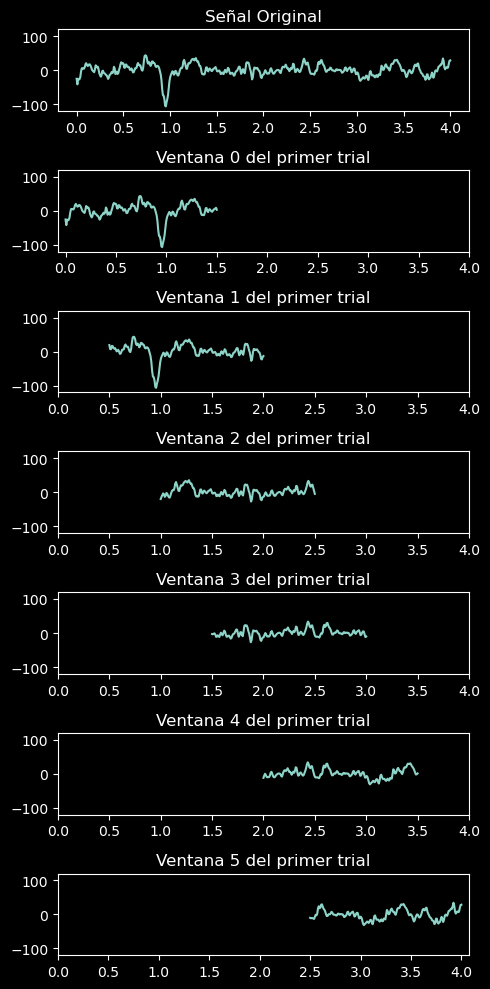

In [11]:
# grafico en una sola figura las 6 particiones de un mismo trial original
# en la primer fila grafico la señal original
tiempo_original = np.linspace(0, signal.shape[2] / fs, signal.shape[2])
tiempo_segmentado = np.linspace(0, windowed_signal_np.shape[2] / fs, windowed_signal_np.shape[2])

plt.style.use('dark_background')
plt.figure(figsize=(5, 10))
plt.subplot(n_windows_per_trial + 1, 1, 1)
plt.plot(tiempo_original, signal[0, 0, :])
plt.title('Señal Original')
plt.ylim(-120, 120)
plt.xticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])
for i in range(1, n_windows_per_trial + 1):
    plt.subplot(n_windows_per_trial + 1, 1, i+1)
    plt.plot(tiempo_segmentado + 0.5*(i-1), windowed_signal_np[i-1, 0, :]) # Graficar el primer canal de cada ventana
    plt.title(f'Ventana {i-1} del primer trial')
    plt.ylim(-120, 120)
    plt.xticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])
plt.tight_layout()
plt.show()

## Contaminacion de bandas

In [31]:
ejemplo = windowed_signal_np[0, :, :]

def band_defs():
    return {
        'delta': (0.5, 4.0),
        'theta': (4.0, 8.0),
        'alpha': (8.0, 12.0),
        'beta' : (12.0, 32.0),
        'gamma': (32.0, 63.5)
    }

def bandpass_sosfiltfilt(x, low, high, fs, order=4, axis=1):
    """
    Filtrado bandpass usando Butterworth (SOS) + sosfiltfilt con reducción de orden automática
    si filtfilt falla por padlen. x tiene shape (n_channels, n_samples) y el filtrado se aplica
    sobre axis (por defecto axis=1 = tiempo).
    """
    cur_order = int(order)
    last_exception = None
    while cur_order >= 1:
        try:
            sos = butter(cur_order, [low, high], btype='band', fs=fs, output='sos')
            # sosfiltfilt aplica filtrado forward-backward (zero-phase)
            y = sosfiltfilt(sos, x, axis=axis)
            return y
        except Exception as e:
            # si falla por padlen u otra razón numérica, reducimos el orden y probamos de nuevo
            last_exception = e
            cur_order -= 1
    # Si llegamos acá, no pudimos filtrar con sosfiltfilt con órdenes <= original
    raise RuntimeError(f"No se pudo aplicar sosfiltfilt (intentadas órdenes hasta 1). Error final: {last_exception}")

def generate_band_limited_noise_butter(n_channels, n_samples, low, high, fs, order=4, seed=None):
    """
    Genera ruido blanco y lo filtra con el mismo bandpass butterworth (sosfiltfilt).
    """
    rng = np.random.RandomState(seed)
    noise = rng.normal(0, 1, size=(n_channels, n_samples)).astype(float)
    # filtrar ruido en banda
    noise_filt = bandpass_sosfiltfilt(noise, low, high, fs, order=order, axis=1)
    return noise_filt

def compute_energy(x):
    # energía por canal
    return np.sum(x.astype(float)**2, axis=1)

def augment_band_noise_butter(trial, fs=128, factor=0.5, order=4, seed=None, per_channel_scale=True):
    """
    trial: np.array (n_channels, n_samples)
    factor: energía objetivo del ruido = energy(banda_clean) * factor
    order: orden inicial del Butterworth (int). El código intentará reducir si filtfilt falla.
    per_channel_scale: si True escala ruido por canal; si False usa escala global.
    Devuelve dict {band_name: info_dict} con info_dict['augmented'] la señal aumentada.
    """
    assert isinstance(trial, np.ndarray), "trial debe ser numpy array"
    assert trial.ndim == 2, "trial debe tener shape (n_channels, n_samples)"
    bands = band_defs()
    augmented = {}
    n_channels, n_samples = trial.shape
    for i, (bname, (low, high)) in enumerate(bands.items()):
        # 1) extraer componente limpia con butterworth + sosfiltfilt
        band_clean = bandpass_sosfiltfilt(trial, low, high, fs, order=order, axis=1)
        band_energy = compute_energy(band_clean)
        target_energy = band_energy * float(factor)
        
        # 2) generar ruido banda-limitado con el mismo filtro
        noise = generate_band_limited_noise_butter(n_channels, n_samples, low, high, fs, order=order, seed=(None if seed is None else seed + i))
        noise_energy = compute_energy(noise)
        
        # 3) escalar ruido para cumplir target_energy
        eps = 1e-12
        if per_channel_scale:
            scales = np.sqrt((target_energy + eps) / (noise_energy + eps))
            scales = np.clip(scales, 0.0, 1e6)
            noise_scaled = noise * scales[:, None]
        else:
            total_target = np.sum(target_energy)
            total_noise = np.sum(noise_energy) + eps
            global_scale = np.sqrt(total_target / total_noise)
            noise_scaled = noise * global_scale
        
        # 4) sumar ruido al trial original
        augmented_trial = trial.astype(float) + noise_scaled
        
        info = {
            'augmented': augmented_trial,
            'band_clean_energy_per_channel': band_energy,
            'noise_energy_before_scaling_per_channel': noise_energy,
            'noise_energy_after_scaling_per_channel': compute_energy(noise_scaled),
            'factor': factor,
            'band': (low, high),
            'butter_order_used': order
        }
        augmented[bname] = info
    return augmented

In [32]:
aug = augment_band_noise_butter(ejemplo, fs=128, factor=0.5, order=4, seed=123, per_channel_scale=True)

# Resumen de energías para comprobación rápida
for band, info in aug.items():
    e_clean = info['band_clean_energy_per_channel']
    e_noise_before = info['noise_energy_before_scaling_per_channel']
    e_noise_after = info['noise_energy_after_scaling_per_channel']
    print(f"\nBanda: {band} {info['band']} (order {info['butter_order_used']})")
    for ch in range(e_clean.size):
        print(f" ch{ch:02d}: cleanE={e_clean[ch]:8.4f} | noise_before={e_noise_before[ch]:8.4f} | noise_after={e_noise_after[ch]:8.4f}")


Banda: delta (0.5, 4.0) (order 4)
 ch00: cleanE=93244.4898 | noise_before= 26.0016 | noise_after=46622.2449
 ch01: cleanE=117660.8043 | noise_before= 14.2965 | noise_after=58830.4021
 ch02: cleanE=53581.0607 | noise_before=  4.6784 | noise_after=26790.5303
 ch03: cleanE=53543.9448 | noise_before=  9.3423 | noise_after=26771.9724
 ch04: cleanE=33631.6881 | noise_before= 47.3797 | noise_after=16815.8441
 ch05: cleanE=37519.8851 | noise_before= 74.3443 | noise_after=18759.9425

Banda: theta (4.0, 8.0) (order 4)
 ch00: cleanE=19147.4374 | noise_before= 12.0909 | noise_after=9573.7187
 ch01: cleanE=23939.1103 | noise_before=  8.4656 | noise_after=11969.5551
 ch02: cleanE=6898.6459 | noise_before= 13.5734 | noise_after=3449.3229
 ch03: cleanE=14798.8092 | noise_before= 14.9713 | noise_after=7399.4046
 ch04: cleanE=4080.0821 | noise_before=  9.5518 | noise_after=2040.0410
 ch05: cleanE=8343.1165 | noise_before=  6.0887 | noise_after=4171.5583

Banda: alpha (8.0, 12.0) (order 4)
 ch00: cleanE

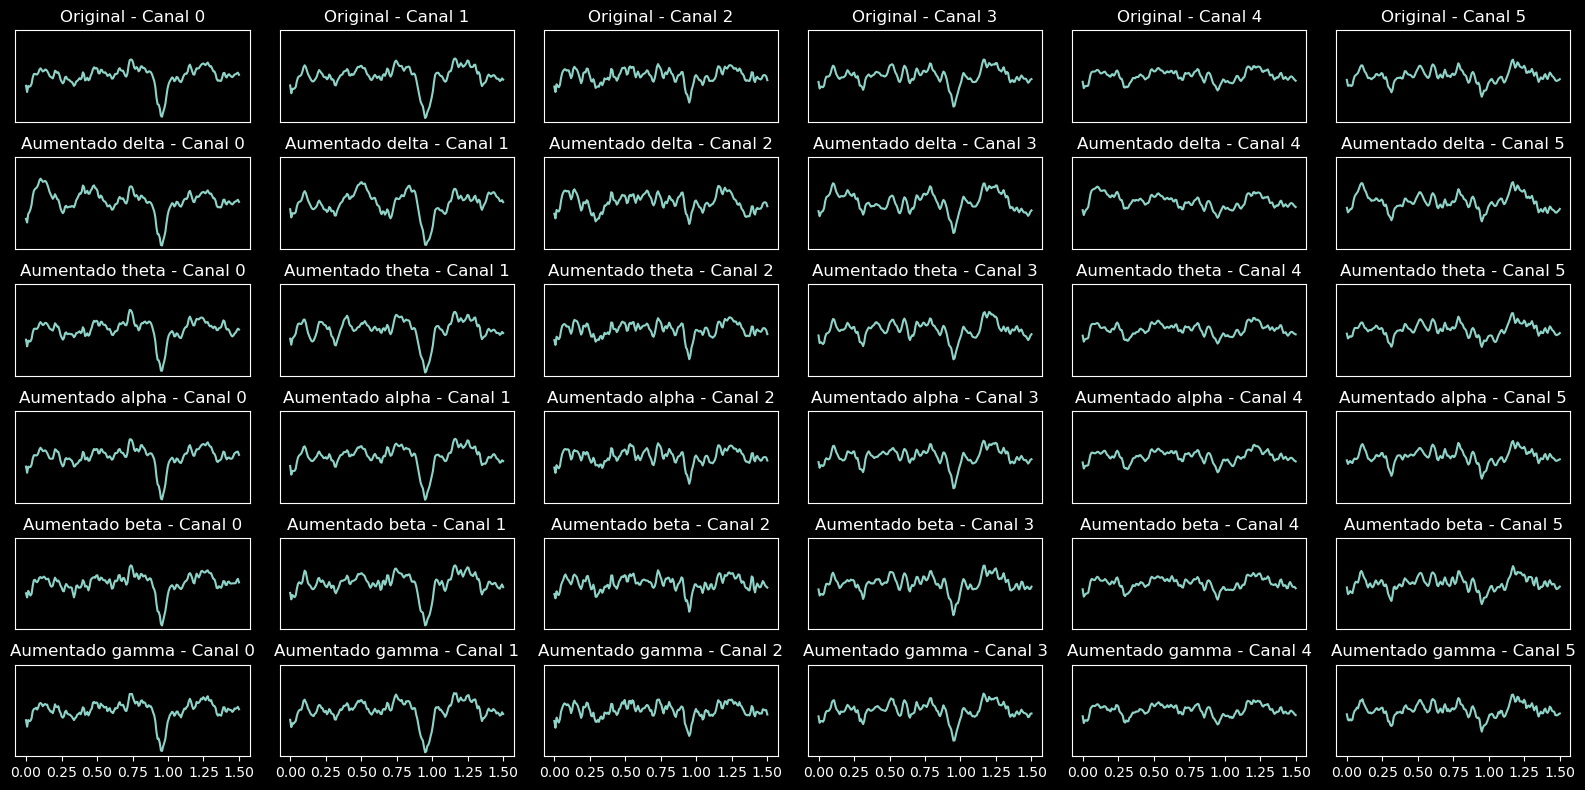

In [33]:
# grafico una figura (5 + 1 aumentaciones, canales)
# la primer fila tiene los 6 canales originales
# las siguientes filas son cada canal con una banda afectada
fig, ax = plt.subplots(len(aug) + 1, 6, figsize=(16, 8))
# Graficar la señal original en la primera fila
for ch in range(6):
    ax[0, ch].plot(tiempo_segmentado, ejemplo[ch, :])
    ax[0, ch].set_title(f'Original - Canal {ch}')
    ax[0, ch].set_xticks([])
    ax[0, ch].set_yticks([])
    ax[0, ch].set_ylim(-120, 120)
# Graficar las señales aumentadas en las filas siguientes
for i, (band_name, info) in enumerate(aug.items()):
    augmented_signal = info['augmented']
    for ch in range(6):
        ax[i + 1, ch].plot(tiempo_segmentado, augmented_signal[ch, :])
        ax[i + 1, ch].set_title(f'Aumentado {band_name} - Canal {ch}')
        ax[i + 1, ch].set_xticks([])
        ax[i + 1, ch].set_yticks([])
        ax[i + 1, ch].set_ylim(-120, 120)
for i in range(6):
    ax[5, i].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])
plt.tight_layout()
plt.show()

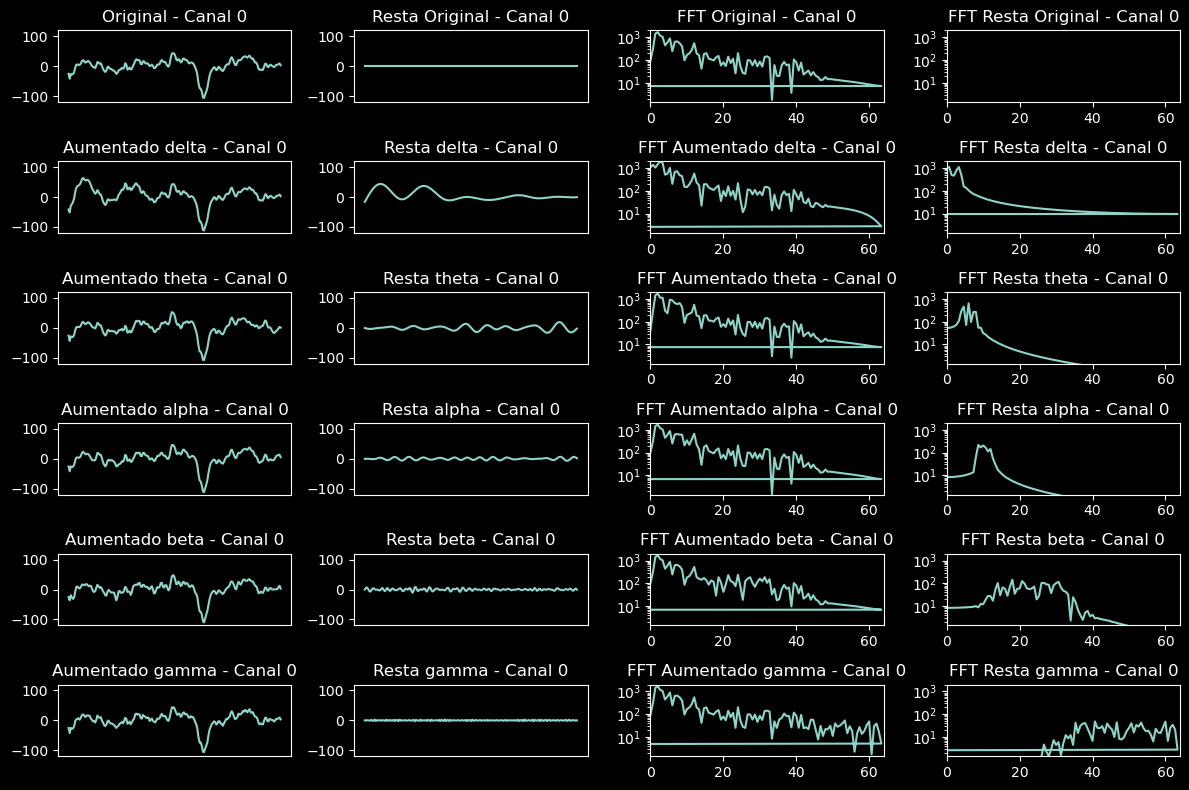

In [34]:
canal = np.random.randint(0, 6)
fig, ax = plt.subplots(6, 4, figsize=(12, 8))
# Graficar la señal
ax[0, 0].plot(tiempo_segmentado, ejemplo[canal, :])
ax[0, 0].set_title(f'Original - Canal {canal}')
ax[0, 0].set_xticks([])
ax[0, 0].set_ylim(-120, 120)
# Graficar la señal resta
ax[0, 1].plot(tiempo_segmentado, ejemplo[canal, :] - ejemplo[canal, :])
ax[0, 1].set_title(f'Resta Original - Canal {canal}')
ax[0, 1].set_xticks([])
ax[0, 1].set_ylim(-120, 120)
# Graficar la FFT de la señal original
eje_freq_segmentado = np.fft.fftfreq(len(ejemplo[canal, :]), 1/fs)
ax[0, 2].plot(eje_freq_segmentado, np.abs(np.fft.fft(ejemplo[canal, :])))
ax[0, 2].set_title(f'FFT Original - Canal {canal}')
ax[0, 2].set_xlim(0, fs//2)
ax[0, 2].set_ylim(0.8*np.min(np.abs(np.fft.fft(ejemplo[canal, :]))), 1.2 * np.max(np.abs(np.fft.fft(ejemplo[canal, :]))))
ax[0, 2].set_yscale('log')
# Graficar la fft de la resta
ax[0, 3].plot(eje_freq_segmentado, np.abs(np.fft.fft(ejemplo[canal, :] - ejemplo[canal, :])))
ax[0, 3].set_title(f'FFT Resta Original - Canal {canal}')
ax[0, 3].set_xlim(0, fs//2)
ax[0, 3].set_ylim(0.8*np.min(np.abs(np.fft.fft(ejemplo[canal, :]))), 1.2 * np.max(np.abs(np.fft.fft(ejemplo[canal, :]))))
ax[0, 3].set_yscale('log')
# Graficar las señales aumentadas y sus FFTs
for i, (band_name, info) in enumerate(aug.items()):
    augmented_signal = info['augmented']
    ax[i + 1, 0].plot(tiempo_segmentado, augmented_signal[canal, :])
    ax[i + 1, 0].set_title(f'Aumentado {band_name} - Canal {canal}')
    ax[i + 1, 0].set_xticks([])
    ax[i + 1, 0].set_ylim(-120, 120)
    
    ax[i + 1, 1].plot(tiempo_segmentado, augmented_signal[canal, :] - ejemplo[canal, :])
    ax[i + 1, 1].set_title(f'Resta {band_name} - Canal {canal}')
    ax[i + 1, 1].set_xticks([])
    ax[i + 1, 1].set_ylim(-120, 120)

    ax[i + 1, 2].plot(eje_freq_segmentado, np.abs(np.fft.fft(augmented_signal[canal, :])))
    ax[i + 1, 2].set_title(f'FFT Aumentado {band_name} - Canal {canal}')
    ax[i + 1, 2].set_xlim(0, fs//2)
    ax[i + 1, 2].set_ylim(0.8*np.min(np.abs(np.fft.fft(ejemplo[canal, :]))), 1.2 * np.max(np.abs(np.fft.fft(ejemplo[canal, :]))))
    ax[i + 1, 2].set_yscale('log')

    ax[i + 1, 3].plot(eje_freq_segmentado, np.abs(np.fft.fft(augmented_signal[canal, :] - ejemplo[canal, :])))
    ax[i + 1, 3].set_title(f'FFT Resta {band_name} - Canal {canal}')
    ax[i + 1, 3].set_xlim(0, fs//2)
    ax[i + 1, 3].set_ylim(0.8*np.min(np.abs(np.fft.fft(ejemplo[canal, :]))), 1.2 * np.max(np.abs(np.fft.fft(ejemplo[canal, :]))))
    ax[i + 1, 3].set_yscale('log')
plt.tight_layout()
plt.show()